# Lab 6 — Linear Regression Evaluation Metrics

**Day 02 · Python for Data Science**

## Goals

1. Train/test split (400/100).
2. Compute R², MSE, MAE, RMSE on held-out data.
3. Compare to mean baseline; preview Ridge/Lasso.

> **Quick check:** train **400** / test **100** · RMSE ≈ **0.69**




## Why this matters <!-- cisco-doc-enrich-2026 -->

Training error lies; **holdout metrics** tell you if the model generalizes. RMSE and R² answer
different questions — RMSE is in rating points; R² is variance explained.

```
full data  --split-->  train (fit)  |  test (score only)
                           |                |
                      coefficients      RMSE, R², MAE
```


## Metric cheat sheet

| Metric | Better when… |
|--------|-------------|
| R² | → 1 |
| MAE/RMSE | → 0 |

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

# cisco-output-ready
print("Imports loaded.")


Imports loaded.


**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [2]:
GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

# cisco-output-ready
print(f"Setup OK — repo root: {GH_ROOT}")


Setup OK — repo root: C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH


**Step 3** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [3]:
ZOMATO_CSV = GH_ROOT / "data" / "zomato" / "zomato_restaurants.csv"
OUTPUT_DIR = GH_ROOT / "hands-on" / "02-python-for-data-science" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

from sklearn.linear_model import LinearRegression

df = pd.read_csv(ZOMATO_CSV)
FEATURES = ["votes", "average_cost_for_two"]
TARGET = "aggregate_rating"

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

X = df[FEATURES]
y = df[TARGET]
print("Full dataset:", len(df), "rows")

# cisco-debug-summary
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
print("dtypes:", df.dtypes.to_dict())

Full dataset: 500 rows
Loaded 500 rows x 9 columns
dtypes: {'restaurant_id': dtype('O'), 'name': dtype('O'), 'city': dtype('O'), 'cuisines': dtype('O'), 'aggregate_rating': dtype('float64'), 'votes': dtype('int64'), 'average_cost_for_two': dtype('int64'), 'online_order': dtype('O'), 'book_table': dtype('O')}


---

## 1. Train/test split

In [4]:
TEST_SIZE, RANDOM_STATE = 0.2, 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f"train: {len(X_train)} | test: {len(X_test)}")
assert len(X_train) == 400 and len(X_test) == 100


# cisco-debug-summary
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Positive rate — train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")

train: 400 | test: 100
Train: 400 | Test: 100
Positive rate — train: 370.52% | test: 366.50%


---

## 2. Fit and predict

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"intercept: {model.intercept_:.4f}")
print(f"coefficients: {model.coef_.round(6)}")


intercept: 3.7073
coefficients: [ 0.e+00 -2.e-06]


---

## 3. All four metrics

In [6]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mse ** 0.5
metrics = pd.DataFrame({"metric": ["R2", "MSE", "MAE", "RMSE"],
                        "value": [r2, mse, mae, rmse]})
display(metrics.round(4))
print(f"RMSE: {rmse:.4f}")


,metric,value
0,R2,-0.0031
1,MSE,0.4695
2,MAE,0.5975
3,RMSE,0.6852


RMSE: 0.6852


### 3b. Metrics table saved to output

In [7]:
out = OUTPUT_DIR / "lr_metrics.json"
metrics.round(4).to_json(out, orient="records", indent=2)
print("saved:", out.name)


saved: lr_metrics.json


---

## 4. Visual diagnostics

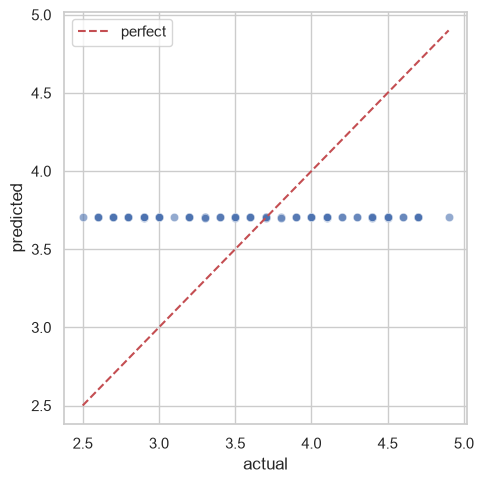

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(x=y_test, y=y_pred, ax=ax, alpha=0.6)
ax.plot([y.min(), y.max()], [y.min(), y.max()], "r--", label="perfect")
ax.set_xlabel("actual"); ax.set_ylabel("predicted")
ax.legend()
plt.tight_layout()
plt.show()

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

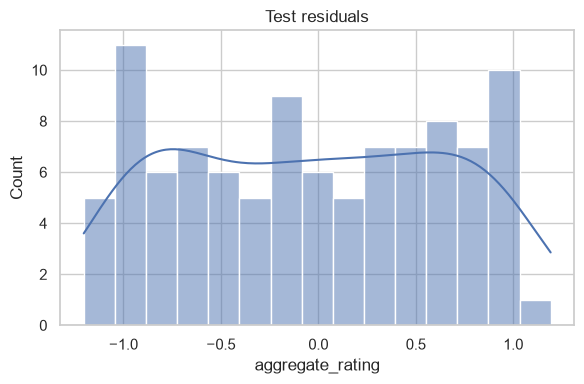

In [9]:
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(residuals, bins=15, kde=True, ax=ax)
ax.set_title("Test residuals")
plt.tight_layout()
plt.show()

---

## 5. Mean baseline comparison

In [10]:
baseline = [y_train.mean()] * len(y_test)
print(f"Baseline RMSE: {mean_squared_error(y_test, baseline) ** 0.5:.4f}")
print(f"Model RMSE:    {rmse:.4f}")
print(f"Model R2:      {r2:.4f}")


Baseline RMSE: 0.6853
Model RMSE:    0.6852
Model R2:      -0.0031


---

## 6. Ridge and Lasso (L1/L2)




In [11]:
from sklearn.linear_model import Lasso, Ridge
import numpy as np

rows = []
for name, m in [("OLS", LinearRegression()), ("Ridge", Ridge(1.0)), ("Lasso", Lasso(0.01, max_iter=5000))]:
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    rows.append({"model": name, "rmse": float(np.sqrt(mean_squared_error(y_test, pred)))})
display(pd.DataFrame(rows).round(4))


# cisco-debug-summary
print("Model fit complete.")

,model,rmse
0,OLS,0.6852
1,Ridge,0.6852
2,Lasso,0.6852


Model fit complete.


### 5b. Experiment — test_size 0.3 (optional)

In [12]:
# Uncomment to explore:
# X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X, y, test_size=0.3, random_state=42)
# m2 = LinearRegression().fit(X_tr2, y_tr2)
# print("30% test RMSE:", (mean_squared_error(y_te2, m2.predict(X_te2)) ** 0.5).round(4))
print("Default: test_size=0.2 → train=400, test=100")


Default: test_size=0.2 → train=400, test=100


---

## 7. Error by rating tier

In [13]:
err_df = pd.DataFrame({"actual": y_test, "predicted": y_pred})
err_df["abs_error"] = (err_df["actual"] - err_df["predicted"]).abs()
err_df["tier"] = pd.cut(err_df["actual"], bins=[0, 3, 3.5, 4, 5], labels=["low", "mid", "good", "top"])
display(err_df.groupby("tier", observed=True)["abs_error"].mean().round(3))


# cisco-debug-summary
print("Groupby complete — compare categories in the table above.")

tier
low     0.898
mid     0.370
good    0.135
top     0.732
Name: abs_error, dtype: float64

Groupby complete — compare categories in the table above.


---

## 8. Final checkpoint

In [14]:
assert len(X_train) == 400 and len(X_test) == 100
assert abs(rmse - 0.6852) < 0.02
print("Numbers match — you're good.")
print("\nDay 02 complete — Day 03 introduces Lending Club classification.")



Numbers match — you're good.



Day 02 complete — Day 03 introduces Lending Club classification.
